In [1]:
# Характеристика 

# Исследование нелинейного МНК

In [2]:
from testing import testing
import numpy as np
import matplotlib.pyplot as plt

## Иследование на количество итераций

Зависимотсть среднего критерия от числа итераций алгоритма. 

Бесшумные данные. 45 поворотов.

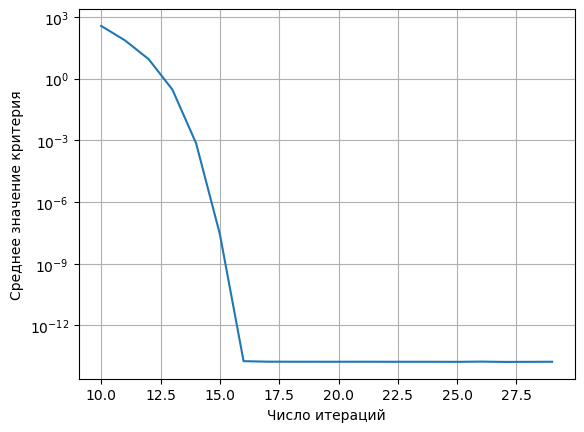

27


In [16]:
iter_num = 30
model_num = 1000

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

Зашумленные данные

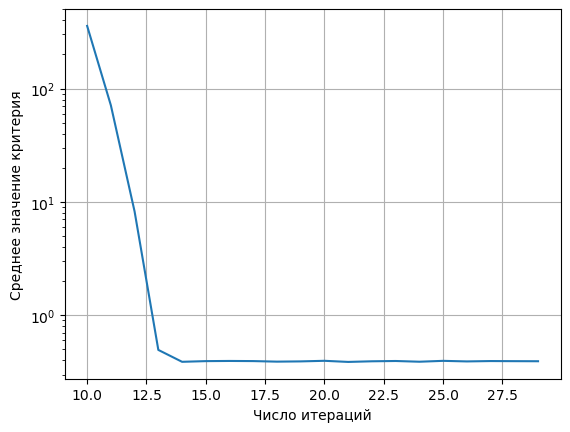

21


In [4]:
iter_num = 30
model_num = 1000

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

## Исследование стабильности критерия

Интервальный ряд критериев. Его статистические параметры.

Бесшумные данные. 45 поворотов. 30 итераций.

0
Выборочное мат. ожидание:  1.7308110500380282e-14
Выборочное СКО:  3.856756263105599e-15


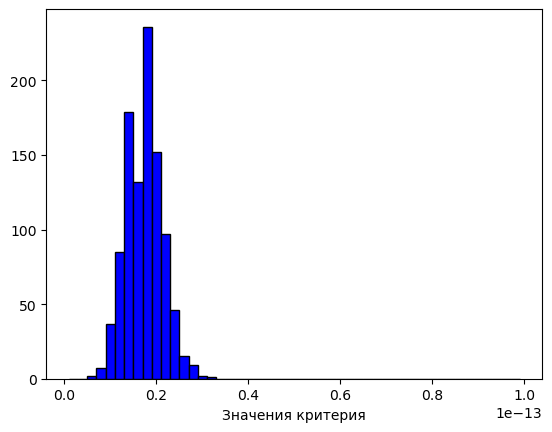

In [5]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if crit > 1e-13:
        deads += 1
        continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(1e-15, 1e-13, 2e-15))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

Зашумленные данные

0
Выборочное мат. ожидание:  0.3927115120421845
Выборочное СКО:  0.06896694423988653


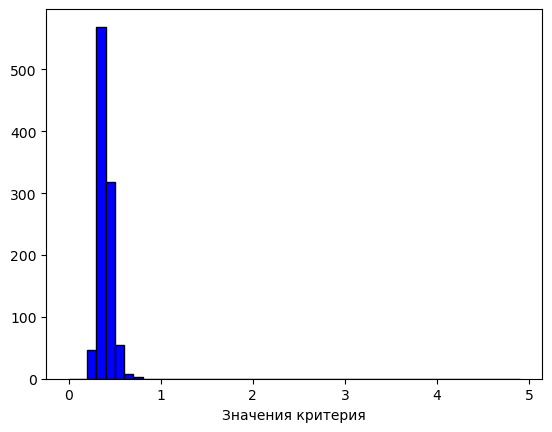

In [6]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    # if crit > 1e-13:
    #     deads += 1
    #     continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(0, 5, 0.1))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

## Исследование относительной ошибки коэффициентов

Безшумные данные

0 0.0


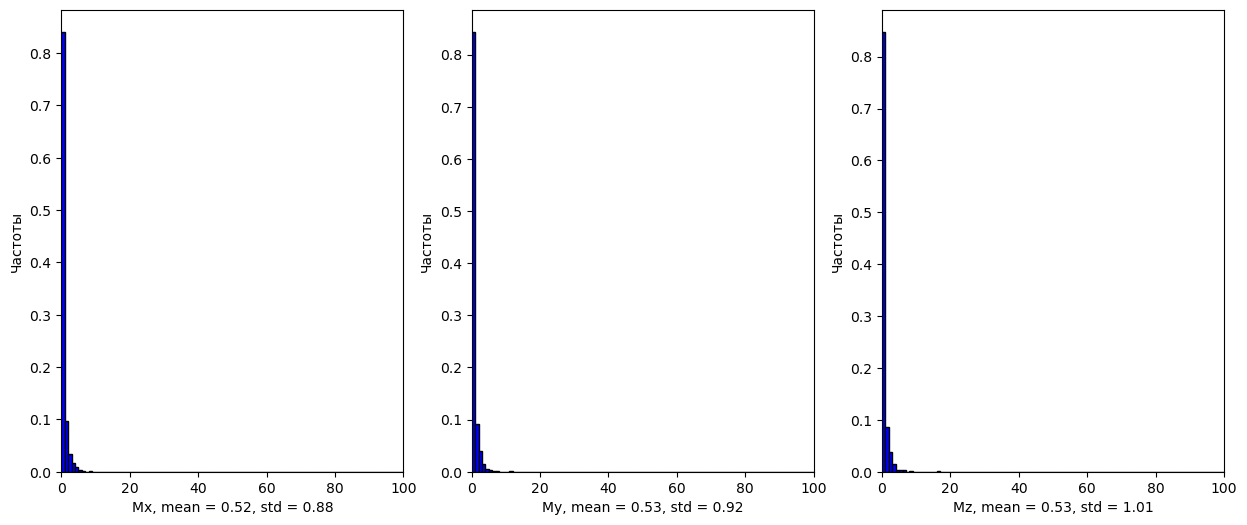

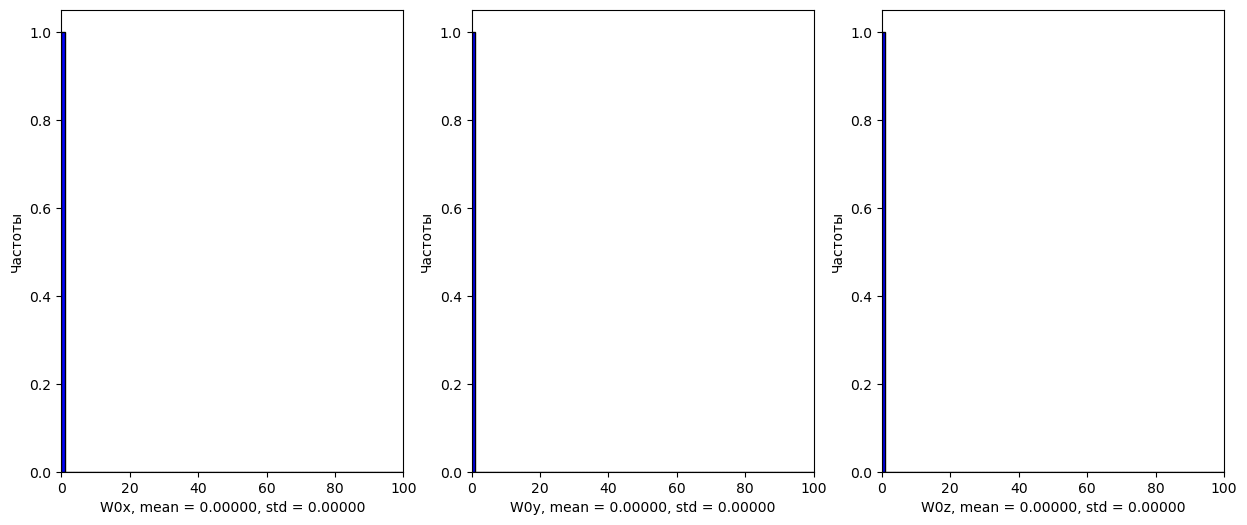

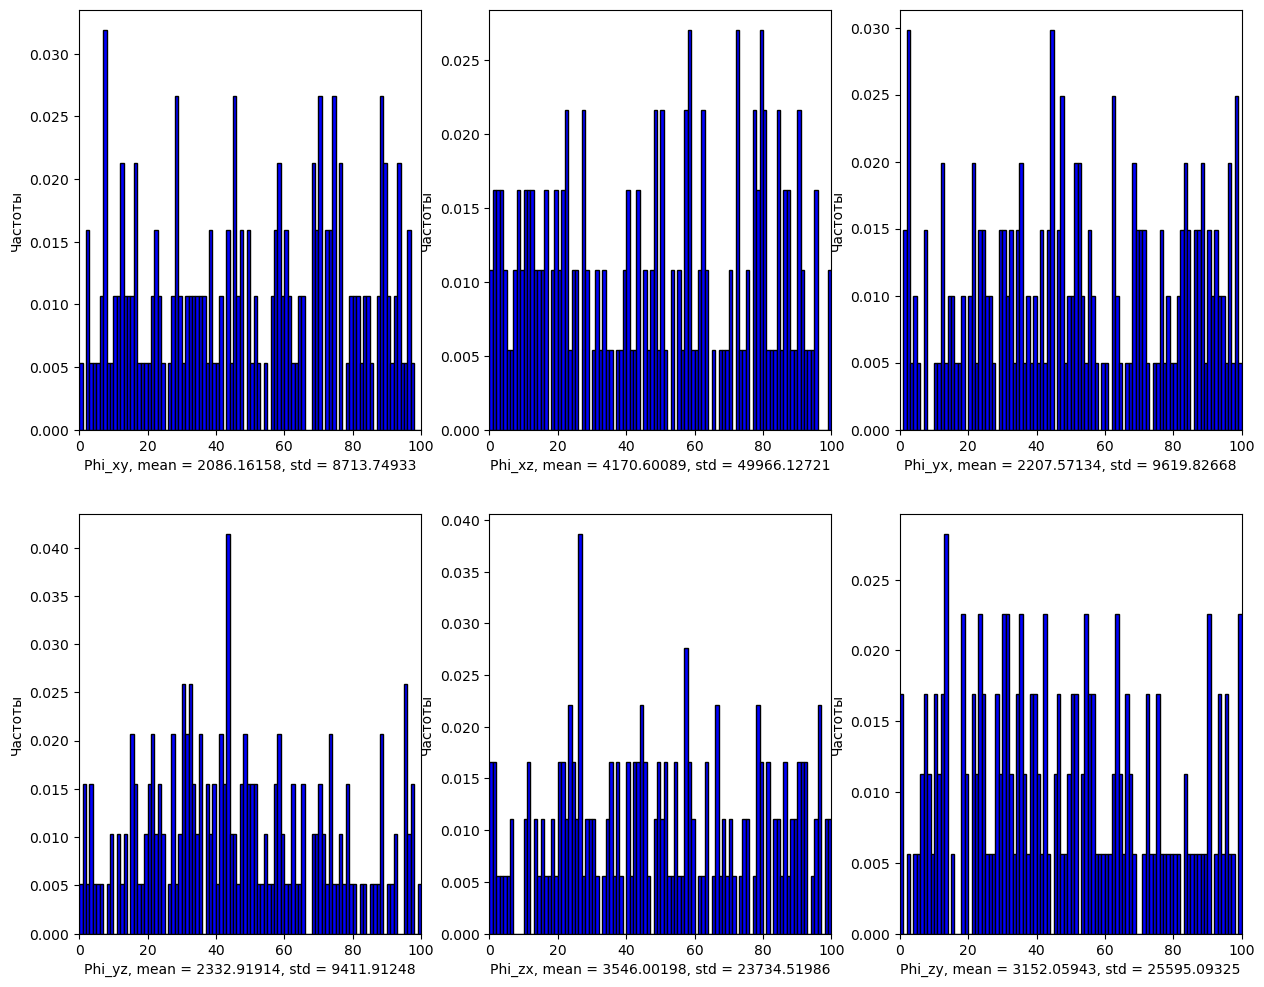

In [7]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

Зашумленные данные

46 0.046


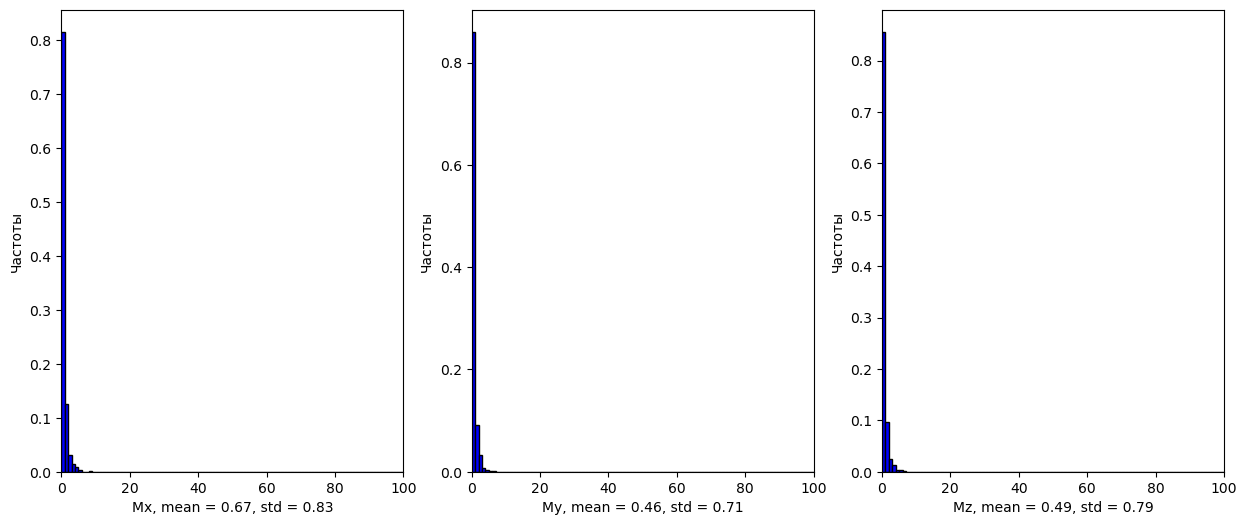

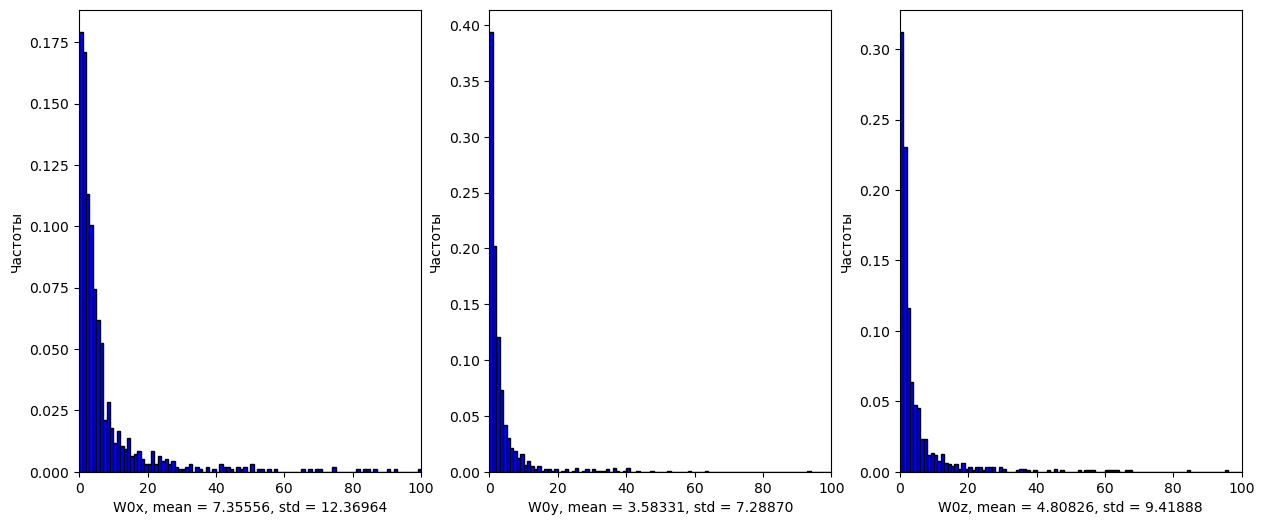

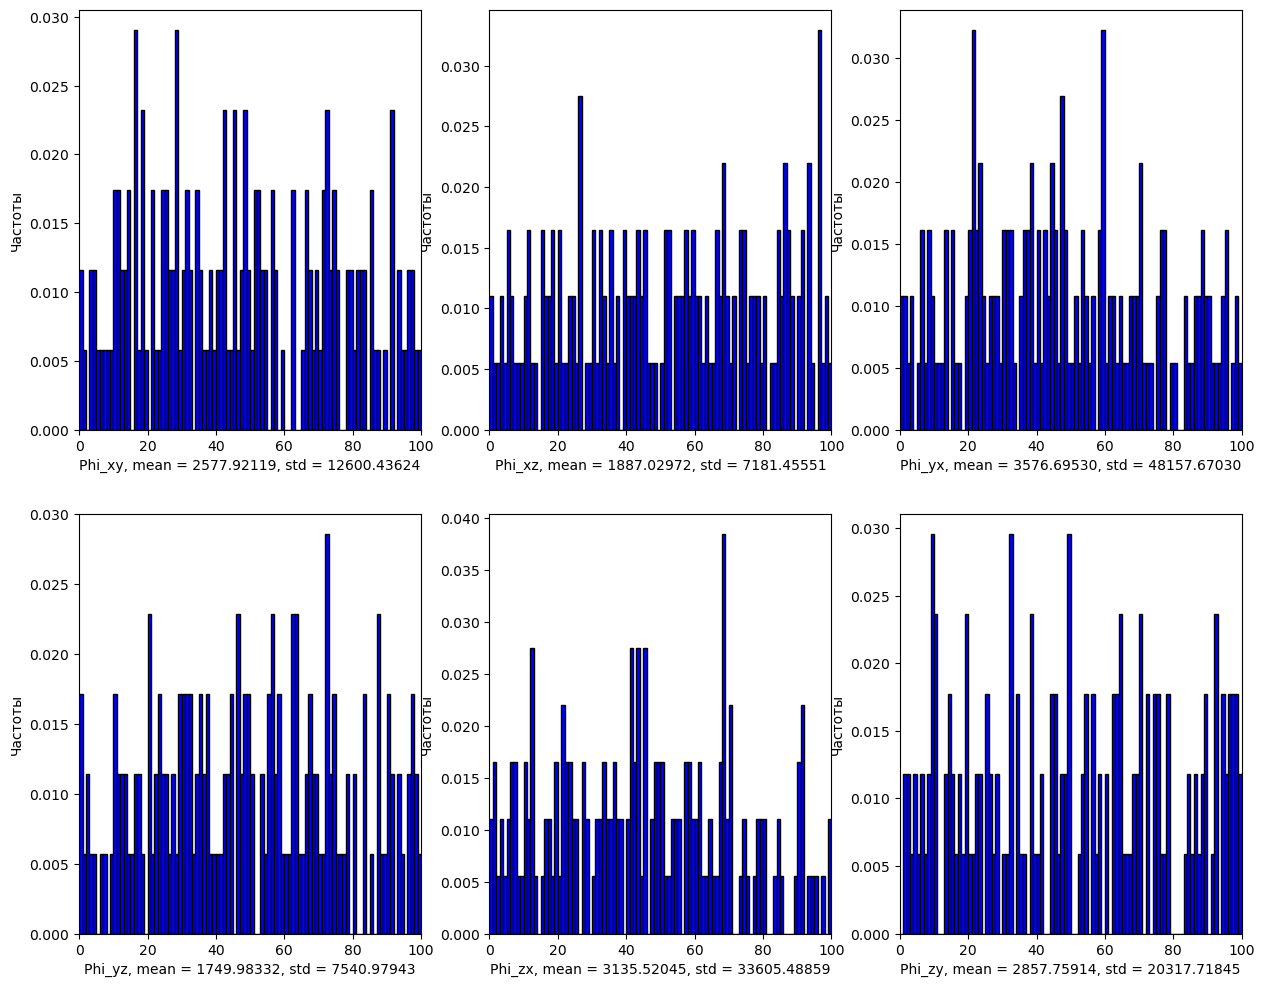

In [8]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

# Исследование распределения асолютных ошибок определения параметров

0 0.0


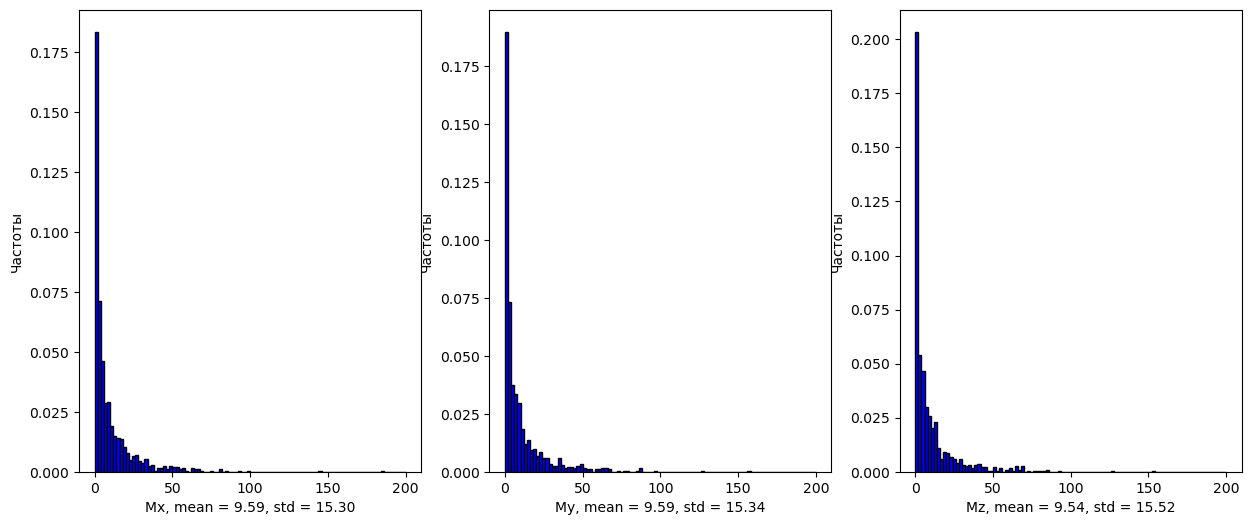

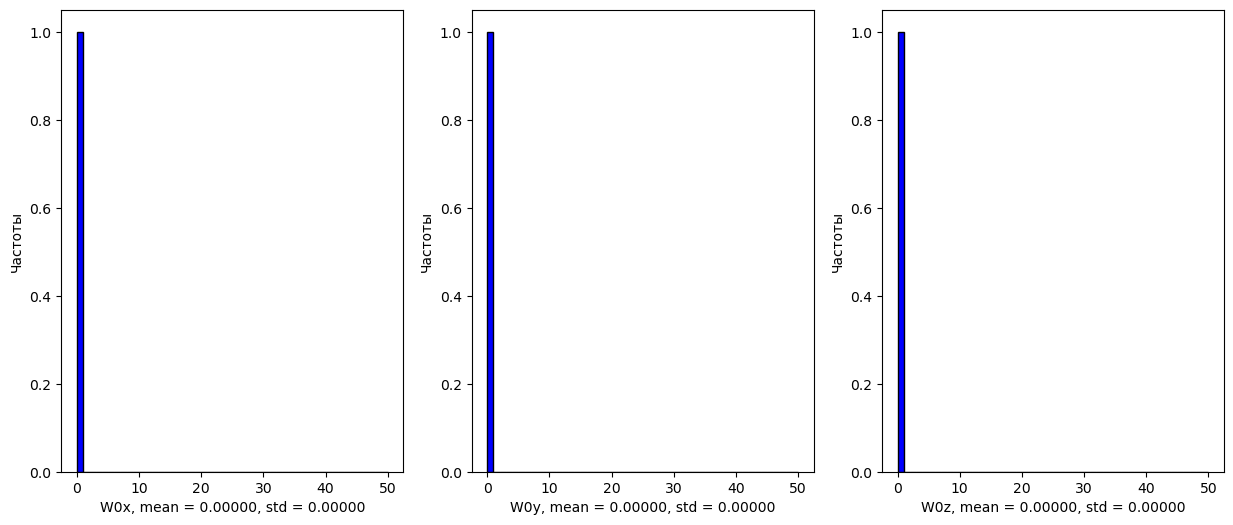

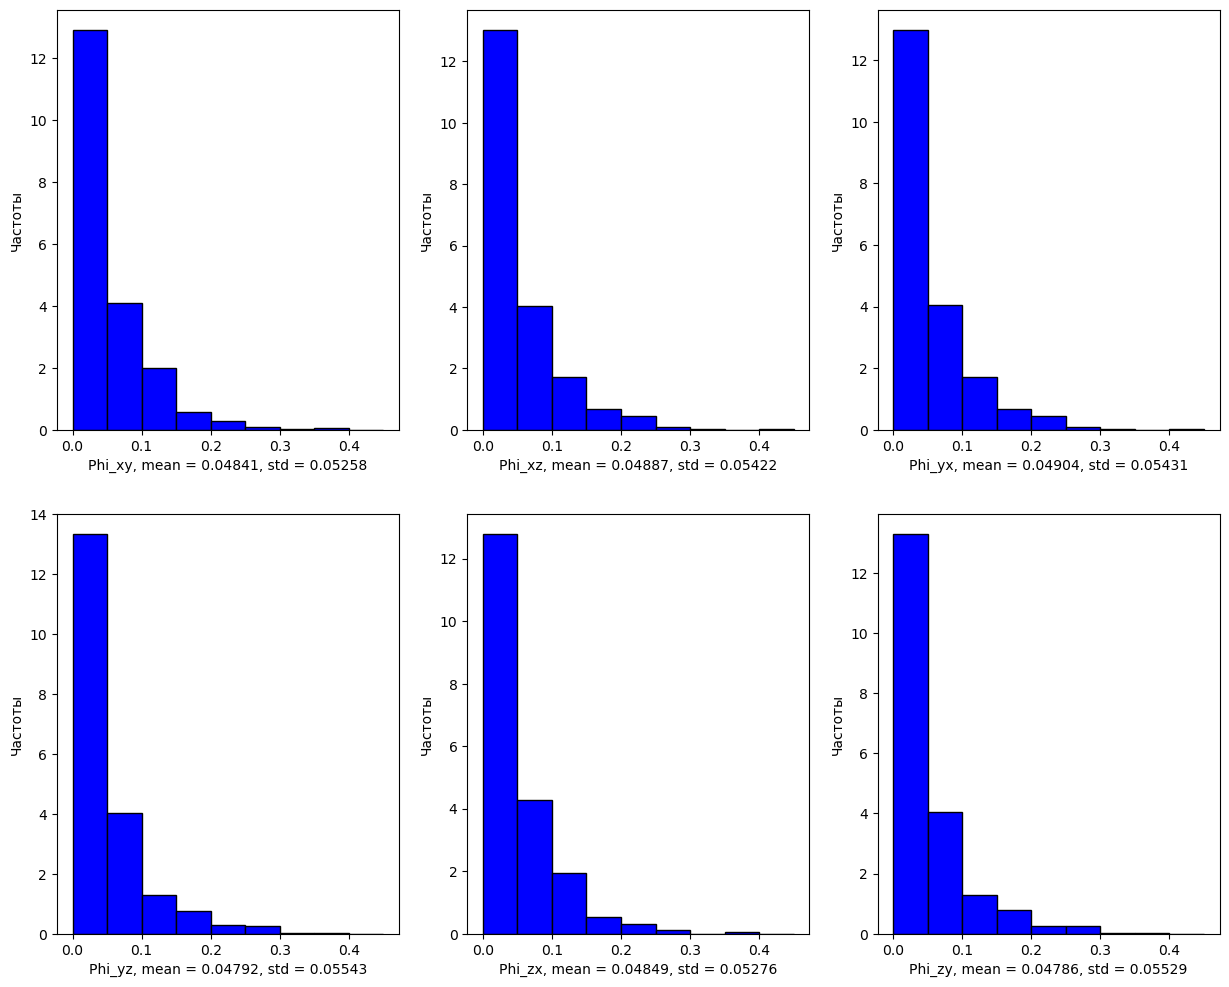

In [9]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 2)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 0.5, 0.05)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

Зашумленные данные

52 0.052


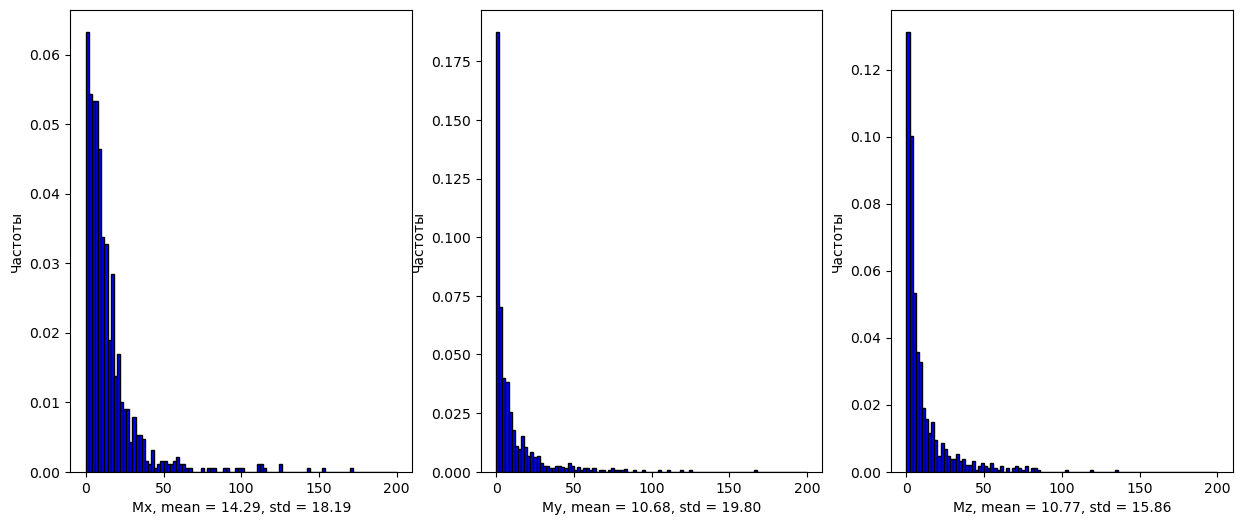

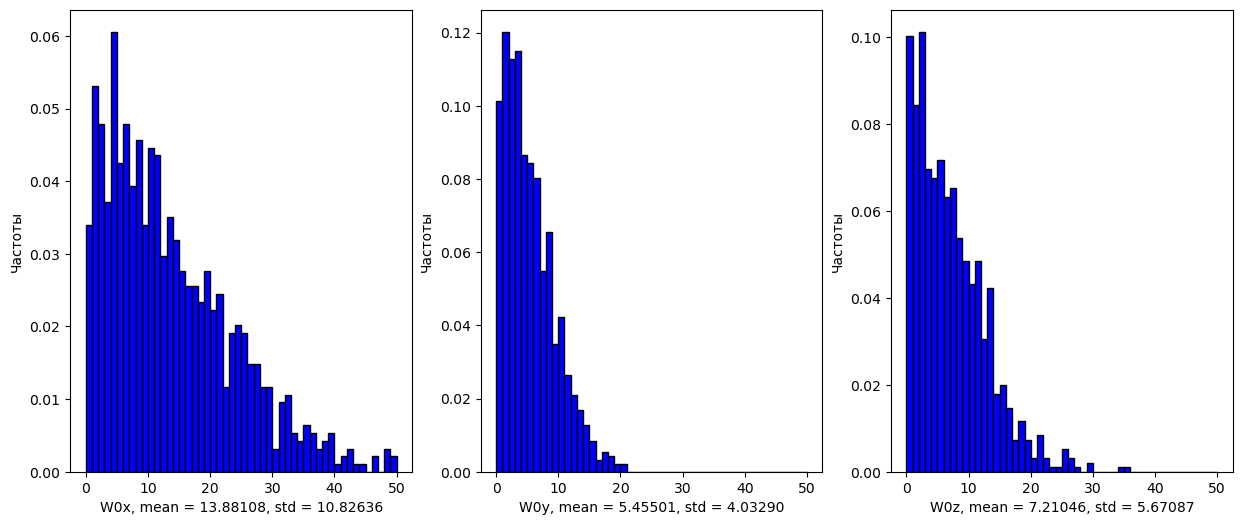

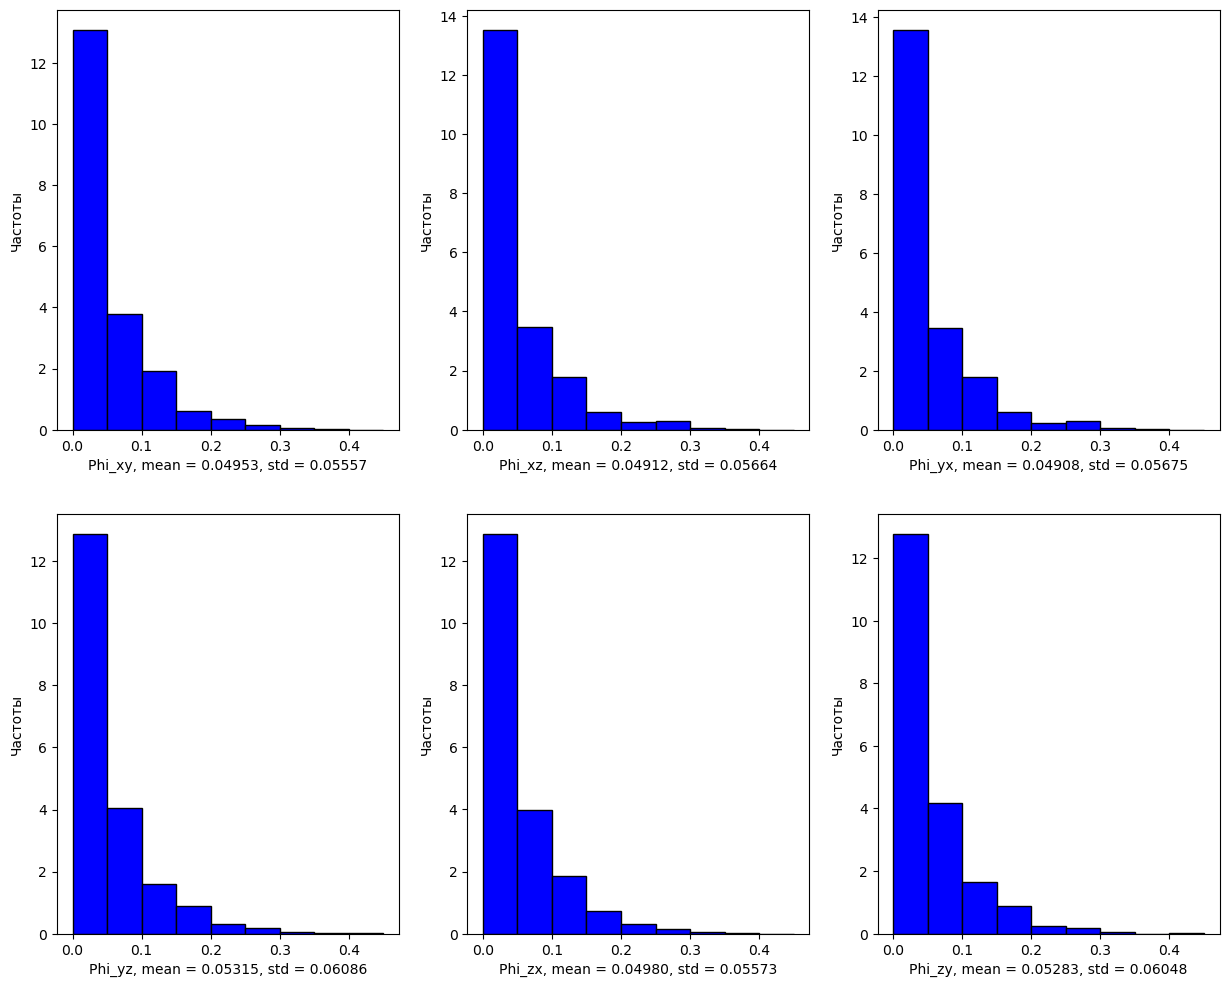

In [10]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 2)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

plt.figure(3, figsize=(15, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 0.5, 0.05)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    # plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+6]}, mean = {np.mean(res[axis_name[i+6]]):.5f}, std = {np.std(res[axis_name[i+6]]):.5f}')
    plt.ylabel('Частоты')

# Изменение критерия относительно параметра

Зависимость J(M_x)

2211.685011674978


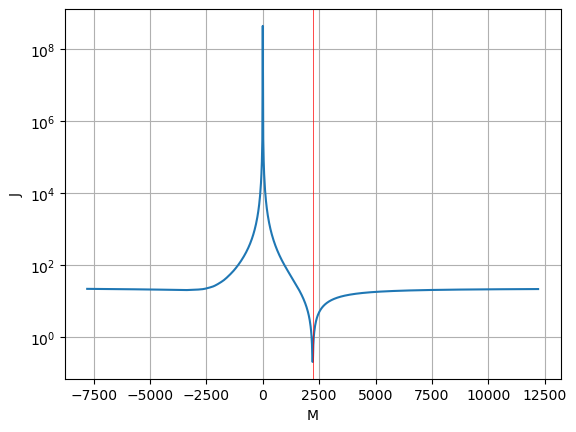

In [11]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tM[0, 0]
edge = 10000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [n, tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

Зависимость J(r0)

-306.4128095808118


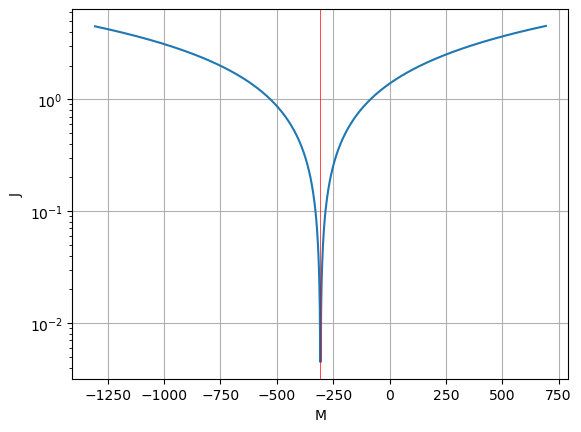

In [12]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tw0[0, 0]
edge = 1000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                n, tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

Зависимость J(phi)

0.016734694180885478


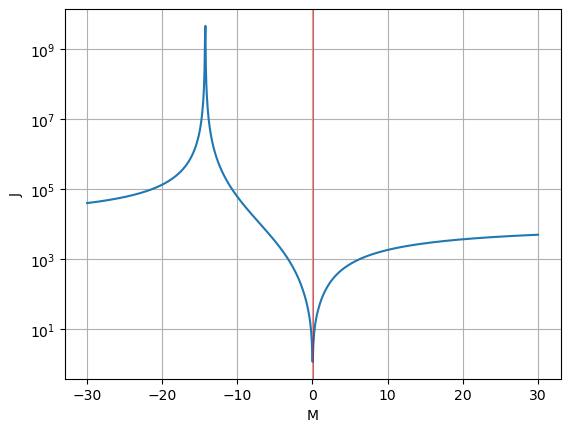

In [13]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tphi[0, 0]
edge = 30
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], n, tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

# Испытания на реальном датчике

Моделирование вращения при параметрах датчика:

Испытания с реальными данными

In [14]:
testing(2, 1, debug=True, func_params=[25], conf_name='home_imu.conf', log_name='logs/long.log')


--- Результат калибровки ---
По осям:

Ось x
M true: 1673.80958    1673.37171    0.03%
r0 true: 384.37    388.99    1.20%

Ось y
M true: 1672.71193    1664.29219    0.50%
r0 true: -72.74    -198.29    172.59%

Ось z
M true: 1686.17655    1687.71170    0.09%
r0 true: 689.26    662.85    3.83%

Phi xz: 116.51%
Phi yx: 52.96%
Phi xy: 76.33%
Phi yz: 74.95%
Phi zx: 46.50%
Phi zy: 149.96%
[[0.01033708]]
0.3525003606313682


(0.3525003606313682,
 [0.026160046028229696,
  0.5033584636820857,
  0.09104282890921557,
  116.51390854526247,
  52.961318555660675,
  76.32564071083641,
  74.95436804260746,
  46.502508100403475,
  149.96076131899892,
  1.201860434499787,
  172.5855580126644,
  3.8308582486229774],
 [0.4378693570915857,
  8.419737055588485,
  1.5351428356536871,
  0.011651390854526246,
  0.005296131855566068,
  0.00763256407108364,
  0.007495436804260746,
  0.004650250810040348,
  0.014996076131899893,
  4.619566914878135,
  125.54563832073205,
  26.4044203301288])

In [15]:
testing(2, 1, debug=True, func_params=[25], conf_name='home_imu.conf', log_name='logs/fast.log')


--- Результат калибровки ---
По осям:

Ось x
M true: 1673.80958    1677.70293    0.23%
r0 true: 384.37    296.85    22.77%

Ось y
M true: 1672.71193    1676.20990    0.21%
r0 true: -72.74    -1.03    98.58%

Ось z
M true: 1686.17655    1698.38315    0.72%
r0 true: 689.26    666.92    3.24%

Phi xz: 20.78%
Phi yx: 173.94%
Phi xy: 137.06%
Phi yz: 148.64%
Phi zx: 39.08%
Phi zy: 66.21%
[[0.01593798]]
3.4279211531551286


(3.4279211531551286,
 [0.2326041306571012,
  0.20912015771008932,
  0.7239216310562878,
  20.777956568214968,
  173.93571673672977,
  137.06155222237427,
  148.63682947589413,
  39.077111780259585,
  66.20522993001394,
  22.769386085649064,
  98.5843021738661,
  3.240070171386674],
 [3.8933502272038822,
  3.4979778189529043,
  12.206596816087085,
  0.002077795656821497,
  0.01739357167367298,
  0.013706155222237426,
  0.014863682947589415,
  0.003907711178025959,
  0.006620522993001395,
  87.51823390968747,
  71.71416477335686,
  22.332378060492942])